<a href="https://colab.research.google.com/github/Sultoniromadhon/data-science-2026/blob/main/Pertemuan12_Sultoni_Romadhon_250401020198.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Nama : SULTONI ROMADHON
* NIM : 250401020198
* Kelas : IF403
* Prodi : Informatika PJJ S1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.metrics.pairwise import cosine_similarity

np.random.seed(42)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [2]:
produk = [
    'Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
    'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega'
]

# Membuat 50 transaksi
transaksi = []

for _ in range(50):
    n_item = np.random.randint(2, 6)
    transaksi.append(
        list(np.random.choice(produk, n_item, replace=False))
    )

# Menambahkan pola Roti -> Selai
for i in range(20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print("Contoh transaksi:")
for t in transaksi[:5]:
    print(t)

print("\nJumlah transaksi:", len(transaksi))

Contoh transaksi:
[np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai']
[np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')]
[np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]
[np.str_('Selai'), np.str_('Keju'), np.str_('Telur'), np.str_('Teh')]
[np.str_('Mentega'), np.str_('Susu'), np.str_('Gula'), np.str_('Keju')]

Jumlah transaksi: 50


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [3]:
from collections import Counter

counter = Counter()

for trx in transaksi:
    counter.update(trx)

frekuensi = pd.DataFrame({
    "Produk": list(counter.keys()),
    "Frekuensi": list(counter.values())
})

frekuensi = frekuensi.sort_values(
    "Frekuensi",
    ascending=False
)

print(frekuensi)

    Produk  Frekuensi
4    Selai         26
5      Teh         23
2  Mentega         21
7    Telur         18
0     Keju         17
1     Roti         16
3     Kopi         16
6     Susu         16
8     Gula         16
9   Sereal          9


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

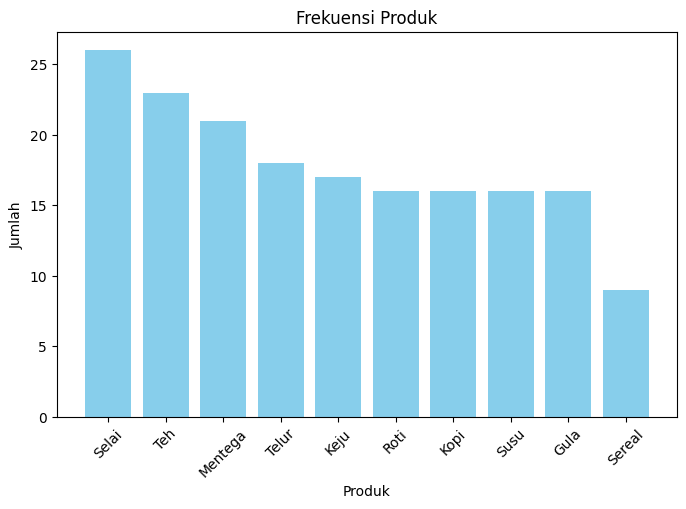

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [4]:
plt.figure(figsize=(8,5))

plt.bar(
    frekuensi["Produk"],
    frekuensi["Frekuensi"],
    color="skyblue"
)

plt.title("Frekuensi Produk")
plt.xlabel("Produk")
plt.ylabel("Jumlah")

plt.xticks(rotation=45)
plt.show()

In [5]:
te = TransactionEncoder()

te_ary = te.fit(transaksi).transform(transaksi)

df = pd.DataFrame(
    te_ary,
    columns=te.columns_
)

print(df.head())

    Gula   Keju   Kopi  Mentega   Roti  Selai  Sereal   Susu    Teh  Telur
0  False   True   True     True   True   True   False  False  False  False
1  False  False   True     True   True   True   False  False   True  False
2  False  False   True    False  False  False   False   True   True  False
3  False   True  False    False  False   True   False  False   True   True
4   True   True  False     True  False  False   False   True  False  False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [6]:
for ms in [0.05, 0.1, 0.2]:
    freq = apriori(
        df,
        min_support=ms,
        use_colnames=True
    )

    print(f"min_support={ms}: {len(freq)} itemset ditemukan")

min_support=0.05: 74 itemset ditemukan
min_support=0.1: 44 itemset ditemukan
min_support=0.2: 13 itemset ditemukan


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [7]:
#Gunakan nilai support 0.1
freq_items = apriori(
    df,
    min_support=0.1,
    use_colnames=True
)

freq_items = freq_items.sort_values(
    "support",
    ascending=False
)

print(freq_items.head(10))

    support      itemsets
5      0.52       (Selai)
8      0.46         (Teh)
3      0.42     (Mentega)
9      0.36       (Telur)
1      0.34        (Keju)
0      0.32        (Gula)
2      0.32        (Kopi)
4      0.32        (Roti)
7      0.32        (Susu)
36     0.24  (Teh, Selai)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [8]:
rules = association_rules(
    freq_items,
    metric="confidence",
    min_threshold=0.5
)

rules = rules[
    rules["lift"] > 1
].sort_values(
    "lift",
    ascending=False
)

print(
    rules[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].head(10)
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

         antecedents consequents  support  confidence      lift
9        (Keju, Teh)     (Telur)     0.12    0.857143  2.380952
14  (Mentega, Selai)      (Kopi)     0.10    0.625000  1.953125
12      (Gula, Roti)     (Selai)     0.10    1.000000  1.923077
7           (Sereal)   (Mentega)     0.14    0.777778  1.851852
10      (Telur, Teh)      (Keju)     0.12    0.600000  1.764706
15     (Kopi, Selai)   (Mentega)     0.10    0.714286  1.700680
8      (Keju, Telur)       (Teh)     0.12    0.750000  1.630435
11     (Gula, Selai)      (Roti)     0.10    0.500000  1.562500
13   (Kopi, Mentega)     (Selai)     0.10    0.714286  1.373626
1             (Roti)     (Selai)     0.22    0.687500  1.322115


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Interpretasi:

1. Aturan dengan nilai Lift tertinggi merupakan hubungan pembelian yang paling kuat.

2. Jika muncul aturan:
   Roti → Selai

   maka aturan tersebut masuk akal karena pada dataset memang telah
   disisipkan pola bahwa pembeli roti sering membeli selai.

3. Nilai Lift > 1 menunjukkan bahwa kedua produk lebih sering muncul
   bersama dibandingkan jika pembelian terjadi secara acak.

In [9]:
katalog = pd.DataFrame({
    "produk": produk,
    "kategori": [
        "Bakery",
        "Bakery",
        "Dairy",
        "Bakery",
        "Dairy",
        "Dairy",
        "Minuman",
        "Bumbu",
        "Minuman",
        "Dairy"
    ]
})

print(katalog)

    produk kategori
0     Roti   Bakery
1    Selai   Bakery
2     Susu    Dairy
3   Sereal   Bakery
4    Telur    Dairy
5     Keju    Dairy
6     Kopi  Minuman
7     Gula    Bumbu
8      Teh  Minuman
9  Mentega    Dairy


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [10]:
fitur = pd.get_dummies(katalog["kategori"])

sim_matrix = cosine_similarity(fitur)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [11]:
def rekomendasi_serupa(nama_produk, top_n=3):

    idx = katalog.index[
        katalog["produk"] == nama_produk
    ][0]

    skor = list(enumerate(sim_matrix[idx]))

    skor = sorted(
        skor,
        key=lambda x: x[1],
        reverse=True
    )

    skor = [
        s for s in skor
        if s[0] != idx
    ][:top_n]

    return katalog.iloc[
        [i for i, _ in skor]
    ]["produk"].tolist()

print("Mirip dengan Roti:")
print(rekomendasi_serupa("Roti"))

Mirip dengan Roti:
['Selai', 'Sereal', 'Susu']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [12]:
produk_target = "Roti"

rules_terkait = rules[
    rules["antecedents"].apply(
        lambda x: produk_target in x
    )
]

print("Rekomendasi dari Association Rules")
print(
    rules_terkait[
        ["consequents", "lift"]
    ].head()
)

print()

print("Rekomendasi dari Content-Based")
print(rekomendasi_serupa(produk_target))

Rekomendasi dari Association Rules
   consequents      lift
12     (Selai)  1.923077
1      (Selai)  1.322115

Rekomendasi dari Content-Based
['Selai', 'Sereal', 'Susu']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Perbandingan:

Association Rules
- Berdasarkan pola pembelian pelanggan.
- Contohnya menghasilkan rekomendasi Selai untuk pembeli Roti.

Content-Based Filtering
- Berdasarkan kemiripan atribut produk.
- Karena Roti termasuk kategori Bakery, maka produk Bakery lain
  seperti Selai dan Sereal dapat direkomendasikan.

Kesimpulan:
- Association Rules lebih baik jika tersedia data transaksi yang banyak.
- Content-Based cocok ketika data transaksi masih sedikit tetapi
  informasi produk tersedia.
- Pada sistem rekomendasi modern, kedua metode sering digabungkan
  (Hybrid Recommendation System) agar rekomendasi menjadi lebih akurat.

#Kesimpulan

Pada praktikum ini dipelajari dua metode rekomendasi.

1. Association Rules menggunakan algoritma Apriori untuk menemukan pola pembelian yang sering muncul secara bersamaan pada data transaksi.

2. Content-Based Filtering memberikan rekomendasi berdasarkan kemiripan karakteristik produk, yaitu kategori produk.

Association Rules lebih efektif apabila tersedia banyak data transaksi pelanggan, sedangkan Content-Based Filtering dapat digunakan meskipun belum memiliki riwayat transaksi. Menggabungkan kedua metode (Hybrid Recommendation System) dapat menghasilkan rekomendasi yang lebih relevan dan akurat.